# Problem description

You are to predict whether a company will go bankrupt in the following year, based on financial attributes of the company.

Perhaps you are contemplating lending money to a company, and need to know whether the company
is in near-term danger of not being able to repay.


## Goal

## Learning objectives

- Demonstrate mastery on solving a classification problem and presenting
the entire Recipe for Machine Learning process in a notebook.
- We will make suggestions for ways to approach the problem
    - But there will be little explicit direction for this task.
- It is meant to be analogous to a pre-interview task that a potential employer might assign
to verify your skill

# Import modules

In [1]:
print('Work By: \nRhugved Bhojane')

Work By: 
Rhugved Bhojane


In [2]:
## Standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn

import os
import math

%matplotlib inline

# API for students

In [3]:
## Load the bankruptcy_helper module

from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

# Reload all modules imported with %aimport
%load_ext autoreload
%autoreload 1

# Import bankruptcy_helper module
import bankruptcy_helper
%aimport bankruptcy_helper

helper = bankruptcy_helper.Helper()

# Get the data

The first step in our Recipe is Get the Data.

- Each example is a row of data corresponding to a single company
- There are 64 attributes, described in the section below
- The column `Bankrupt` is 1 if the company subsequently went bankrupt; 0 if it did not go bankrupt
- The column `Id` is a Company Identifier

In [4]:
# Data directory
DATA_DIR = "./Data"

if not os.path.isdir(DATA_DIR):
    DATA_DIR = "../resource/asnlib/publicdata/bankruptcy/data"

data_file = "5th_yr.csv"
data = pd.read_csv( os.path.join(DATA_DIR, "train", data_file) )

target_attr = "Bankrupt"

n_samples, n_attrs = data.shape
print("Date shape: ", data.shape)

Date shape:  (4818, 66)


## Have a look at the data

We will not go through all steps in the Recipe, nor in depth.

But here's a peek

In [5]:
data.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X57,X58,X59,X60,X61,X62,X63,X64,Bankrupt,Id
0,0.025417,0.41769,0.0568,1.1605,-126.39,0.41355,0.025417,1.2395,1.16500,0.51773,...,0.049094,0.85835,0.12322,5.6167,7.4042,164.310,2.2214,1.334,0,4510
1,-0.023834,0.2101,0.50839,4.2374,22.034,0.058412,-0.027621,3.6579,0.98183,0.76855,...,-0.031011,1.01850,0.069047,5.7996,7.7529,26.446,13.802,6.4782,0,3537
2,0.030515,0.44606,0.19569,1.565,35.766,0.28196,0.039264,0.88456,1.05260,0.39457,...,0.077337,0.95006,0.25266,15.049,2.8179,104.730,3.4852,2.6361,0,3920
3,0.052318,0.056366,0.54562,10.68,438.2,0.13649,0.058164,10.853,1.02790,0.61173,...,0.085524,0.97282,0,6.0157,7.4626,48.756,7.4863,1.0602,0,1806
4,0.000992,0.49712,0.12316,1.3036,-71.398,0,0.001007,1.0116,1.29210,0.50288,...,0.001974,0.99925,0.019736,3.4819,8.582,114.580,3.1854,2.742,0,1529


Pretty *unhelpful* !

What are these mysteriously named features ?

## Description of attributes

This may still be somewhat unhelpful for those of you not used to reading Financial Statements.

But that's partially the point of the exercise
- You can *still* perform Machine Learning *even if* you are not an expert in the problem domain
    - That's what makes this a good interview exercise: you can demonstrate your thought process even if you don't know the exact meaning of the terms
- Of course: becoming an expert in the domain *will improve* your ability to create better models
    - Feature engineering is easier if you understand the features, their inter-relationships, and the relationship to the target

Let's get a feel for the data
- What is the type of each attribute ?


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4818 entries, 0 to 4817
Data columns (total 66 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   X1        4818 non-null   object 
 1   X2        4818 non-null   object 
 2   X3        4818 non-null   object 
 3   X4        4818 non-null   object 
 4   X5        4818 non-null   object 
 5   X6        4818 non-null   object 
 6   X7        4818 non-null   object 
 7   X8        4818 non-null   object 
 8   X9        4818 non-null   float64
 9   X10       4818 non-null   object 
 10  X11       4818 non-null   object 
 11  X12       4818 non-null   object 
 12  X13       4818 non-null   float64
 13  X14       4818 non-null   object 
 14  X15       4818 non-null   object 
 15  X16       4818 non-null   object 
 16  X17       4818 non-null   object 
 17  X18       4818 non-null   object 
 18  X19       4818 non-null   float64
 19  X20       4818 non-null   float64
 20  X21       4818 non-null   obje

You may be puzzled:
- Most attributes are `object` and *not* numeric (`float64`)
- But looking at the data via `data.head()` certainly gives the impression that all attributes are numeric

Welcome to the world of messy data !  The dataset has represented numbers as strings.
- These little unexpected challenges are common in the real-word
- Data is rarely perfect and clean

So you might want to first convert all attributes to numeric

**Hint**
- Look up the Pandas method `to_numeric`
    - We suggest you use the option `errors='coerce'`
    

# Evaluating your project

We will evaluate your submission on a test dataset that we provide
- It has no labels, so **you** can't use it to evaluate your model, but **we** have the labels
- We will call this evaluation dataset the "holdout" data

Let's get it

As suggested apply method implement

In [7]:
data = data.apply(pd.to_numeric, errors='coerce')

In [8]:
holdout_data = pd.read_csv( os.path.join(DATA_DIR, "holdout", '5th_yr.csv') )
print("Data shape: ", holdout_data.shape)
holdout_data = holdout_data.apply(pd.to_numeric,errors='coerce')

Data shape:  (1092, 65)


Used the Helper file functions to get the files 

In [9]:
def load_data_from_folders(train_folder, holdout_folder):
    return helper.load_data_from_folders(train_folder, holdout_folder)

In [10]:
train_folder = "./train"
holdout_folder = "./holdout"

In [11]:
train_data, holdout_data = helper.load_data_from_folders(train_folder, holdout_folder)

In [12]:
y_train = train_data.iloc[:, -1].values
X_train = train_data.iloc[:, :-1].values
y_holdout = holdout_data.iloc[:, -1].values
X_holdout = holdout_data.iloc[:, :-1].values

In [73]:
'''column_mapping = {
    "X1": "Net Profit / Total Assets",
    "X2": "Total Liabilities / Total Assets",
    "X3": "Working Capital / Total Assets",
    "X4": "Current Assets / Short-Term Liabilities",
    "X5": "Cash & Securities / Operating Expenses",
    "X6": "Retained Earnings / Total Assets",
    "X7": "EBIT / Total Assets",
    "X8": "Book Value of Equity / Total Liabilities",
    "X9": "Sales / Total Assets",
    "X10": "Equity / Total Assets",
    "X11": "Gross Profit & Financial Expenses / Total Assets",
    "X12": "Gross Profit / Short-Term Liabilities",
    "X13": "Gross Profit & Depreciation / Sales",
    "X14": "Gross Profit & Interest / Total Assets",
    "X15": "Total Liabilities * 365 / Gross Profit & Depreciation",
    "X16": "Gross Profit & Depreciation / Total Liabilities",
    "X17": "Total Assets / Total Liabilities",
    "X18": "Gross Profit / Total Assets",
    "X19": "Gross Profit / Sales",
    "X20": "Inventory * 365 / Sales",
    "X21": "Sales Growth (n/n-1)",
    "X22": "Profit on Operating Activities / Total Assets",
    "X23": "Net Profit / Sales",
    "X24": "Gross Profit (3 Years) / Total Assets",
    "X25": "Equity - Share Capital / Total Assets",
    "X26": "Net Profit + Depreciation / Total Liabilities",
    "X27": "Profit on Operating Activities / Financial Expenses",
    "X28": "Working Capital / Fixed Assets",
    "X29": "Logarithm of Total Assets",
    "X30": "(Total Liabilities - Cash) / Sales",
    "X31": "Gross Profit & Interest / Sales",
    "X32": "Current Liabilities * 365 / Cost of Products Sold",
    "X33": "Operating Expenses / Short-Term Liabilities",
    "X34": "Operating Expenses / Total Liabilities",
    "X35": "Profit on Sales / Total Assets",
    "X36": "Total Sales / Total Assets",
    "X37": "(Current Assets - Inventories) / Long-Term Liabilities",
    "X38": "Constant Capital / Total Assets",
    "X39": "Profit on Sales / Sales",
    "X40": "(Current Assets - Inventory - Receivables) / Short-Term Liabilities",
    "X41": "Total Liabilities / (Profit on Operating Activities + Depreciation) * (12/365)",
    "X42": "Profit on Operating Activities / Sales",
    "X43": "Receivables & Inventory Turnover in Days",
    "X44": "Receivables * 365 / Sales",
    "X45": "Net Profit / Inventory",
    "X46": "(Current Assets - Inventory) / Short-Term Liabilities",
    "X47": "Inventory * 365 / Cost of Products Sold",
    "X48": "EBITDA / Total Assets",
    "X49": "EBITDA / Sales",
    "X50": "Current Assets / Total Liabilities",
    "X51": "Short-Term Liabilities / Total Assets",
    "X52": "(Short-Term Liabilities * 365) / Cost of Products Sold",
    "X53": "Equity / Fixed Assets",
    "X54": "Constant Capital / Fixed Assets",
    "X55": "Working Capital",
    "X56": "(Sales - Cost of Products Sold) / Sales",
    "X57": "(Current Assets - Inventory - Short-Term Liabilities) / (Sales - Gross Profit - Depreciation)",
    "X58": "Total Costs / Total Sales",
    "X59": "Long-Term Liabilities / Equity",
    "X60": "Sales / Inventory",
    "X61": "Sales / Receivables",
    "X62": "(Short-Term Liabilities * 365) / Sales",
    "X63": "Sales / Short-Term Liabilities",
    "X64": "Sales / Fixed Assets"
}'''

'column_mapping = {\n    "X1": "Net Profit / Total Assets",\n    "X2": "Total Liabilities / Total Assets",\n    "X3": "Working Capital / Total Assets",\n    "X4": "Current Assets / Short-Term Liabilities",\n    "X5": "Cash & Securities / Operating Expenses",\n    "X6": "Retained Earnings / Total Assets",\n    "X7": "EBIT / Total Assets",\n    "X8": "Book Value of Equity / Total Liabilities",\n    "X9": "Sales / Total Assets",\n    "X10": "Equity / Total Assets",\n    "X11": "Gross Profit & Financial Expenses / Total Assets",\n    "X12": "Gross Profit / Short-Term Liabilities",\n    "X13": "Gross Profit & Depreciation / Sales",\n    "X14": "Gross Profit & Interest / Total Assets",\n    "X15": "Total Liabilities * 365 / Gross Profit & Depreciation",\n    "X16": "Gross Profit & Depreciation / Total Liabilities",\n    "X17": "Total Assets / Total Liabilities",\n    "X18": "Gross Profit / Total Assets",\n    "X19": "Gross Profit / Sales",\n    "X20": "Inventory * 365 / Sales",\n    "X21": "

In [13]:
if 'Id' in train_data.columns:
    train_data.drop(columns=['Id'], inplace=True)
if 'Id' in holdout_data.columns:
    holdout_data.drop(columns=['Id'], inplace=True)

In [14]:
missing_cols = set(train_data.columns) - set(holdout_data.columns)
for col in missing_cols:
    holdout_data[col] = np.nan

In [15]:
holdout_data = holdout_data[train_data.columns]

In [16]:
print("Train Data Shape:", train_data.shape)
print("Holdout Data Shape:", holdout_data.shape)
print("Missing Values in Train Data:")
print(train_data.isnull().sum())

Train Data Shape: (4818, 65)
Holdout Data Shape: (1092, 65)
Missing Values in Train Data:
X1          0
X2          0
X3          0
X4          0
X5          0
           ..
X61         0
X62         0
X63         0
X64         0
Bankrupt    0
Length: 65, dtype: int64


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Bankrupt', ylabel='count'>

Text(0.5, 1.0, 'Bankruptcy Class Distribution')

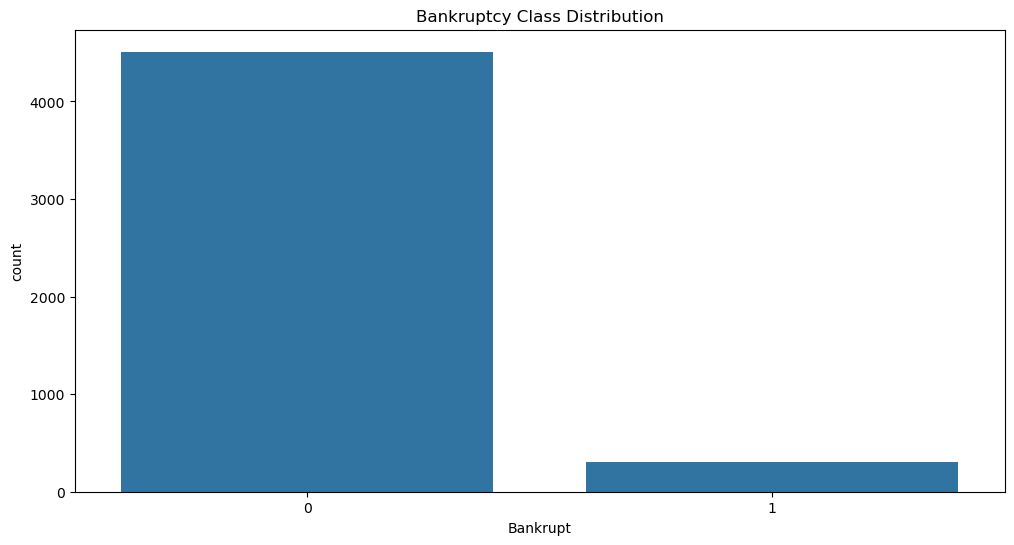

In [17]:
import seaborn as sns 
plt.figure(figsize=(12, 6))
sns.countplot(x=train_data['Bankrupt'])
plt.title("Bankruptcy Class Distribution")
plt.show()

In [18]:
train_data.replace('?', np.nan, inplace=True)
holdout_data.replace('?', np.nan, inplace=True)

/var/folders/t7/dpdxvfdj2l7g8rntzy7zzlm80000gn/T/ipykernel_27414/2686149657.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X_train = X_train.replace('?', np.nan)


<Figure size 1200x800 with 0 Axes>

<Axes: >

Text(0.5, 1.0, 'Feature Correlation Heatmap (Multicollinearity Check)')

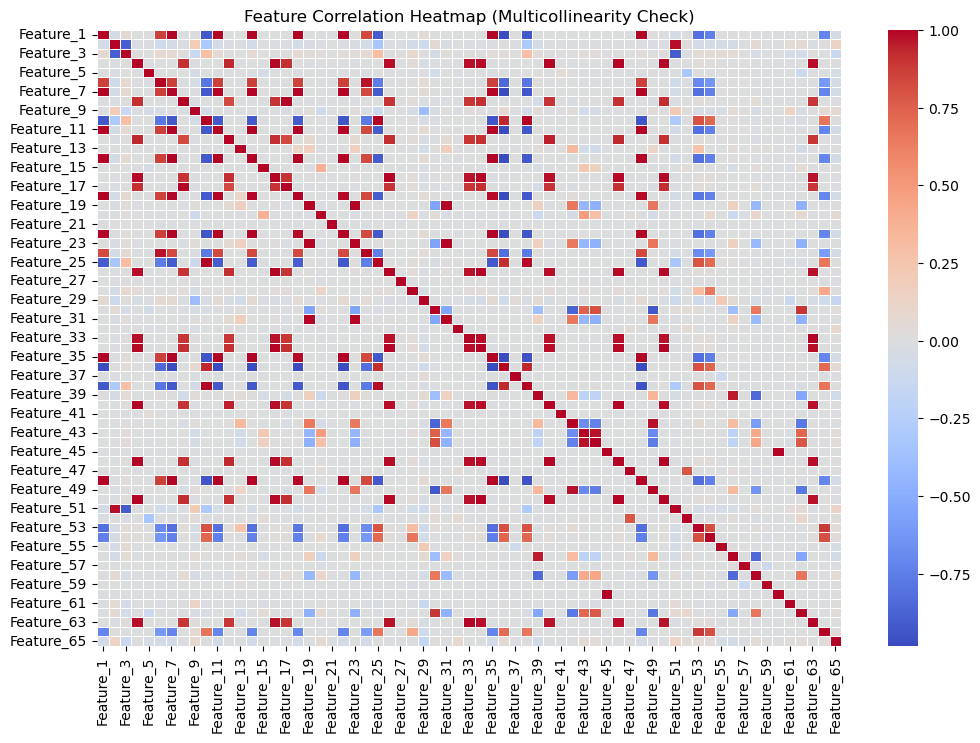

      Feature 1   Feature 2  Correlation
0     Feature_1   Feature_7     0.999983
1     Feature_1  Feature_10    -0.924524
2     Feature_1  Feature_11     0.999953
3     Feature_1  Feature_14     0.999982
4     Feature_1  Feature_18     0.993049
..          ...         ...          ...
131  Feature_43  Feature_44     0.975607
132  Feature_45  Feature_60     0.999904
133  Feature_46  Feature_50     0.995438
134  Feature_46  Feature_63     0.978853
135  Feature_50  Feature_63     0.975809

[136 rows x 3 columns]


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

if isinstance(X_train, np.ndarray):  
    X_train = pd.DataFrame(X_train, columns=[f"Feature_{i+1}" for i in range(X_train.shape[1])])

X_train = X_train.replace('?', np.nan)  
X_train = X_train.apply(pd.to_numeric, errors='coerce')  

X_train.fillna(X_train.mean(), inplace=True)  

correlation_matrix = X_train.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False, fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Heatmap (Multicollinearity Check)")
plt.show()

high_corr_pairs = []
threshold = 0.9  

for i in range(len(correlation_matrix.columns)):
    for j in range(i + 1, len(correlation_matrix.columns)):  # Avoid self-correlation
        if abs(correlation_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((correlation_matrix.columns[i], correlation_matrix.columns[j], correlation_matrix.iloc[i, j]))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"])
print(high_corr_df)


In [20]:
print("\nDescriptive Statistics:")
print(data.describe())


Descriptive Statistics:
                X1           X2           X3           X4            X5  \
count  4816.000000  4816.000000  4816.000000  4803.000000  4.808000e+03   
mean     -0.055232     0.533272     0.188992     4.978602  1.956441e+01   
std       6.707351     1.202909     1.282430   100.273952  2.384491e+04   
min    -463.890000     0.000000   -72.067000     0.000000 -1.076400e+06   
25%       0.004047     0.254670     0.044923     1.099200 -4.312000e+01   
50%       0.046487     0.451495     0.218560     1.642300  3.673450e-01   
75%       0.116730     0.662177     0.420152     2.929200  4.986775e+01   
max       2.352300    72.416000    28.336000  6845.800000  1.250100e+06   

                X6           X7           X8           X9          X10  ...  \
count  4816.000000  4816.000000  4804.000000  4818.000000  4816.000000  ...   
mean     -0.070060    -0.042516     5.739985     1.579277     0.503606  ...   
std       7.778523     6.707970   109.508001     1.342723     

In [21]:
corr_matrix = data.corr()
print("\nCorrelation with Target Variable (Bankrupt):")
print(corr_matrix['Bankrupt'].sort_values(ascending=False)[:11])


Correlation with Target Variable (Bankrupt):
Bankrupt    1.000000
X2          0.138941
X51         0.133746
X32         0.079717
X9          0.076021
X36         0.061178
X20         0.055927
X58         0.052528
X43         0.052071
X44         0.043092
X53         0.041565
Name: Bankrupt, dtype: float64


<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X2', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X2')

Text(0.5, 0, 'X2')

Text(0, 0.5, 'Frequency')

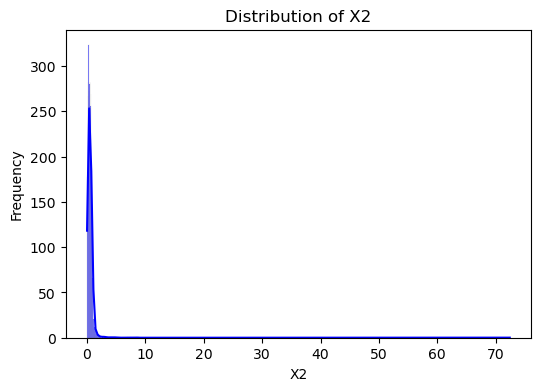

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X51', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X51')

Text(0.5, 0, 'X51')

Text(0, 0.5, 'Frequency')

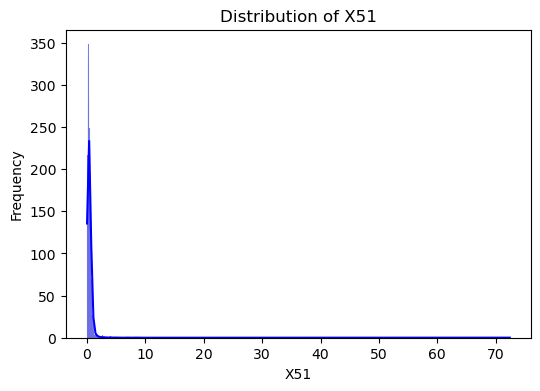

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X32', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X32')

Text(0.5, 0, 'X32')

Text(0, 0.5, 'Frequency')

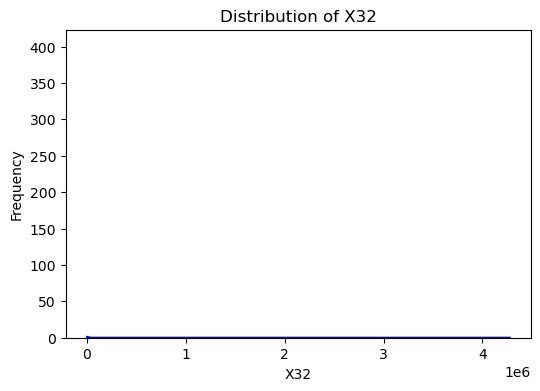

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X9', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X9')

Text(0.5, 0, 'X9')

Text(0, 0.5, 'Frequency')

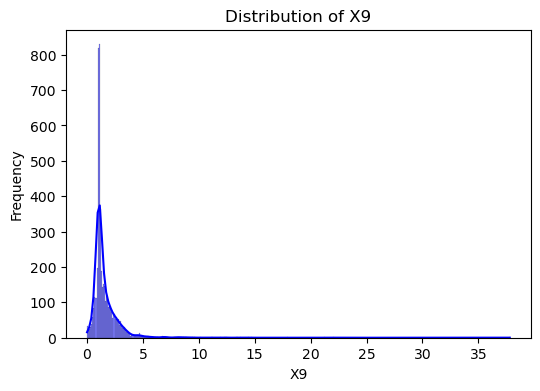

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X36', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X36')

Text(0.5, 0, 'X36')

Text(0, 0.5, 'Frequency')

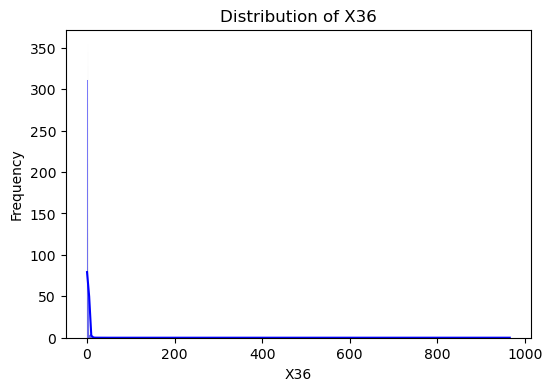

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X20', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X20')

Text(0.5, 0, 'X20')

Text(0, 0.5, 'Frequency')

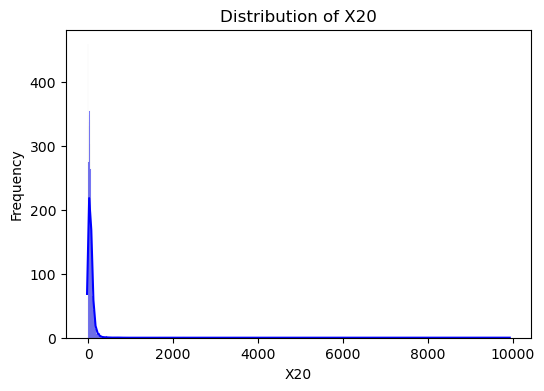

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X58', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X58')

Text(0.5, 0, 'X58')

Text(0, 0.5, 'Frequency')

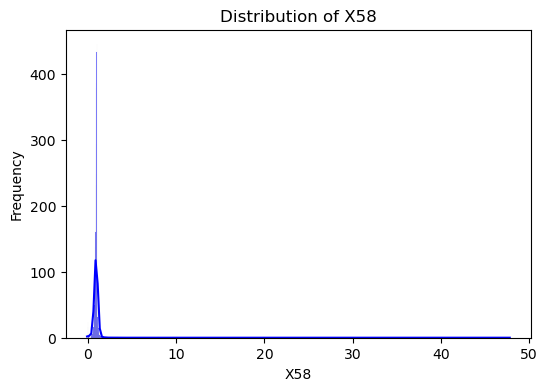

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X43', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X43')

Text(0.5, 0, 'X43')

Text(0, 0.5, 'Frequency')

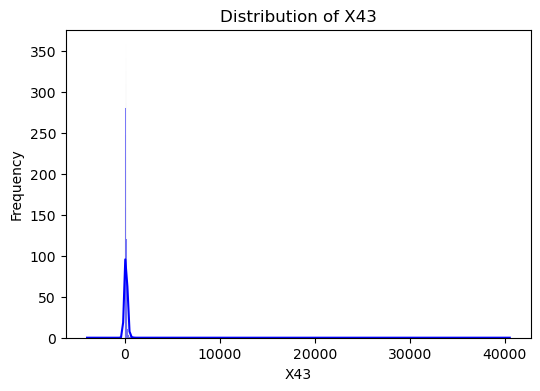

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X44', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X44')

Text(0.5, 0, 'X44')

Text(0, 0.5, 'Frequency')

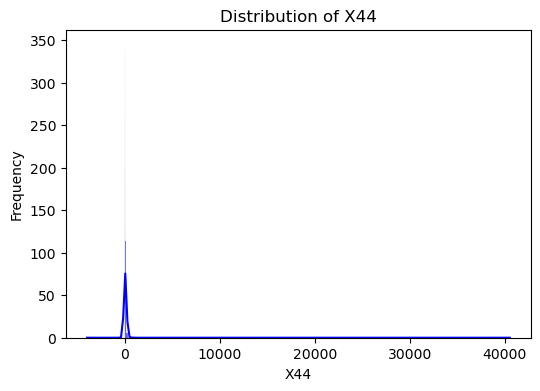

<Figure size 600x400 with 0 Axes>

<Axes: xlabel='X53', ylabel='Count'>

Text(0.5, 1.0, 'Distribution of X53')

Text(0.5, 0, 'X53')

Text(0, 0.5, 'Frequency')

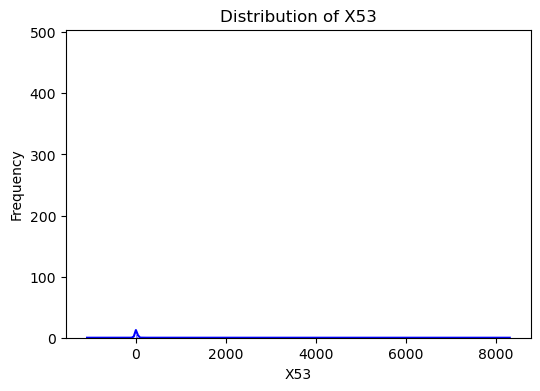

In [22]:
selected_features = ['X2', 'X51', 'X32', 'X9','X36','X20','X58','X43','X44','X53'] 
for feature in selected_features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data[feature], kde=True, color='blue')
    plt.title(f'Distribution of {feature}')
    plt.xlabel(feature)
    plt.ylabel('Frequency')
    plt.show()

In [23]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy='mean')
X_train = train_data.drop(columns=['Bankrupt'])
y_train = train_data['Bankrupt']
X_train = pd.DataFrame(imputer.fit_transform(X_train), columns=X_train.columns)
X_holdout = pd.DataFrame(imputer.transform(holdout_data.drop(columns=['Bankrupt'], errors='ignore')), columns=X_train.columns)

In [24]:
X_train_scaled, y_train = helper.preprocess_data(X_train, y_train)
X_holdout_scaled, y_holdout = helper.preprocess_data(X_holdout, y_holdout)

In [25]:
X_train_scaled.shape
X_holdout_scaled.shape

(4818, 64)

(1092, 64)

In [26]:
y_train.shape
y_holdout.shape

(4818,)

(1092,)

In [27]:
X_train_scaled
#from sklearn.feature_selection import SelectKBest, f_classif
#selector = SelectKBest(f_classif, k=5)  
#X_train_selected = selector.fit_transform(X_train_scaled, y_train)
#X_holdout_selected = selector.transform(X_holdout_scaled)

array([[ 0.01202773, -0.09611536, -0.10311177, ..., -0.00578398,
        -0.06251213, -0.06378727],
       [ 0.0046826 , -0.26874238,  0.24913401, ..., -0.06626451,
         0.03993682, -0.05497203],
       [ 0.01278803, -0.07252352,  0.00522415, ..., -0.03192155,
        -0.0513318 , -0.06155595],
       ...,
       [ 0.00380091, -0.07009532,  0.15784917, ..., -0.06278828,
         0.01178694, -0.02651244],
       [ 0.05070079, -0.3772856 ,  0.21342505, ..., -0.07576783,
         0.59287594, -0.04334541],
       [ 0.02614694,  0.08103545, -0.22932557, ..., -0.04970414,
        -0.03186396, -0.05596593]])

In [29]:
#X_train = X_train[selected_features]
#X_holdout = X_holdout[selected_features]

In [28]:
y_train = (y_train > 0).astype(int)

In [29]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


<Figure size 1200x600 with 0 Axes>

<Axes: xlabel='Bankrupt', ylabel='count'>

Text(0.5, 1.0, 'Bankruptcy Class Distribution')

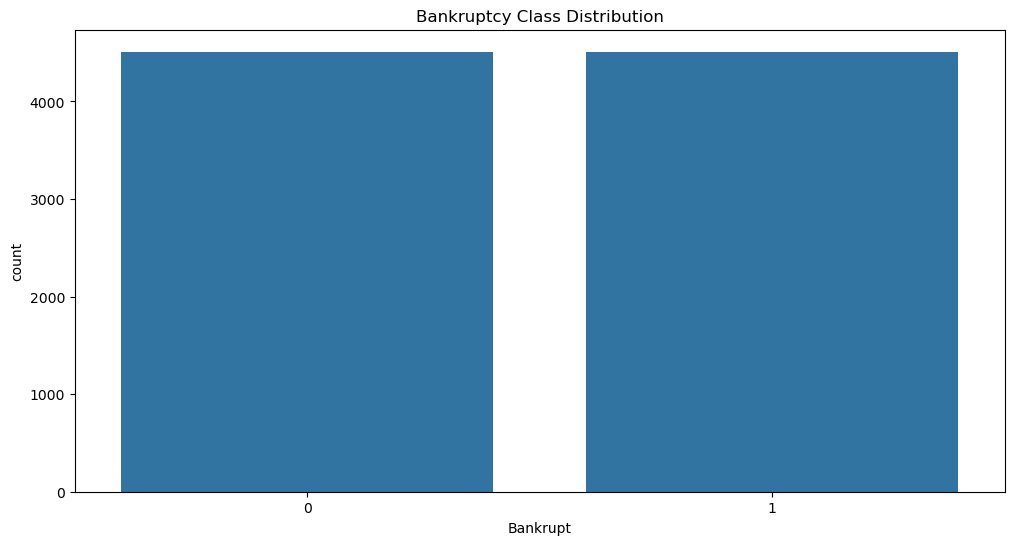

In [30]:
import seaborn as sns 
plt.figure(figsize=(12, 6))
sns.countplot(x=y_train_resampled)
plt.title("Bankruptcy Class Distribution")
plt.show()

In [31]:
X_train_scaled, y_train_resampled = helper.preprocess_data(X_train_resampled.values, y_train_resampled.values)
X_holdout_scaled = helper.preprocess_data(X_holdout.values, None)[0]

In [32]:
def MyModel(data, other={}):
    pred = log_model.predict(data)
    return pred

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [35]:
from sklearn.model_selection import GridSearchCV
logistic_param_grid = {
    'penalty': ['l1', 'l2', 'elasticnet', None], 
    'solver': ['liblinear', 'saga'], 
    'max_iter': [100, 500, 1000] 
}
logistic_grid_search = GridSearchCV(
    estimator=LogisticRegression(random_state=42),  
    param_grid=logistic_param_grid,
    cv=5,  
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)
logistic_grid_search.fit(X_train, y_train)
print("\nBest Parameters for Logistic Regression:", logistic_grid_search.best_params_)
print("Best Logistic Regression Model:", logistic_grid_search.best_estimator_)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


[CV] END ..............max_iter=100, penalty=l1, solver=saga; total time=   0.2s
[CV] END ..............max_iter=100, penalty=l1, solver=saga; total time=   0.2s
[CV] END ..............max_iter=100, penalty=l1, solver=saga; total time=   0.3s
[CV] END .........max_iter=100, penalty=l1, solver=liblinear; total time=   0.3s
[CV] END .........max_iter=100, penalty=l1, solver=liblinear; total time=   0.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached 

[CV] END .........max_iter=100, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END .........max_iter=100, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ..............max_iter=100, penalty=l1, solver=saga; total time=   0.3s
[CV] END ..............max_iter=100, penalty=l1, solver=saga; total time=   0.3s
[CV] END .........max_iter=100, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END ..............max_iter=100, penalty=l2, solver=saga; total time=   0.1s
[CV] END ..............max_iter=100, penalty=l2, solver=saga; total time=   0.1s
[CV] END ..............max_iter=100, penalty=l2, solver=saga; total time=   0.1s
[CV] END .max_iter=100, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END .max_iter=100, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END .........max_iter=100, penalty=l2, solver=liblinear; total time=   0.2s
[CV] END .max_iter=100, penalty=elasticnet, solver=liblinear; total time=   0.0s
[CV] END .max_iter=100, pena

...

[CV] END ...........max_iter=1000, penalty=None, solver=saga; total time=   1.4s
[CV] END .............max_iter=1000, penalty=l2, solver=saga; total time=   1.3s


/opt/anaconda3/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
45 fits failed out of a total of 120.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
15 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *ar

[CV] END .............max_iter=1000, penalty=l2, solver=saga; total time=   1.1s


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'max_iter': [100, 500, 1000],
                         'penalty': ['l1', 'l2', 'elasticnet', None],
                         'solver': ['liblinear', 'saga']},
             scoring='accuracy', verbose=2)


Best Parameters for Logistic Regression: {'max_iter': 100, 'penalty': 'l1', 'solver': 'liblinear'}
Best Logistic Regression Model: LogisticRegression(penalty='l1', random_state=42, solver='liblinear')


In [42]:
log_model = LogisticRegression(max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')
log_model.fit(X_train_scaled, y_train_resampled)

LogisticRegression(max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

In [36]:
#rf_model = RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       #random_state=42)
#rf_model.fit(X_train_scaled, y_train_resampled)

RandomForestClassifier(class_weight='balanced', n_estimators=200,
                       random_state=42)

In [43]:
y_holdout_pred = MyModel(pd.DataFrame(X_holdout_scaled))

In [44]:
y_pred_log = log_model.predict(X_holdout_scaled)

In [45]:
y_prob_log = log_model.predict_proba(X_holdout_scaled)[:, 1]  
threshold = 0.4 
y_pred_thresh_log = (y_prob_log > threshold).astype(int)

In [46]:
print("Logistic Regression Predictions on Holdout Data:", y_pred_thresh_log)

Logistic Regression Predictions on Holdout Data: [1 1 0 ... 1 1 0]


In [47]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix, classification_report
name = "Logistic Regression with Threshold Adjustment"
accuracy_test = accuracy_score(y_train_resampled[:len(y_pred_thresh_log)], y_pred_thresh_log)
recall_test = recall_score(y_train_resampled[:len(y_pred_thresh_log)], y_pred_thresh_log, pos_label=1, average="binary")
precision_test = precision_score(y_train_resampled[:len(y_pred_thresh_log)], y_pred_thresh_log, pos_label=1, average="binary")

print("\t{m:s} Accuracy: {a:3.1%}, Recall {r:3.1%}, Precision {p:3.1%}".format(m=name,
                                                                            a=accuracy_test,
                                                                            r=recall_test,
                                                                            p=precision_test))

	Logistic Regression with Threshold Adjustment Accuracy: 44.0%, Recall 63.9%, Precision 7.3%


In [48]:
conf_matrix = confusion_matrix(y_train_resampled[:len(y_pred_thresh_log)], y_pred_thresh_log)
class_report = classification_report(y_train_resampled[:len(y_pred_thresh_log)], y_pred_thresh_log)

In [49]:
print("Confusion Matrix:\n", conf_matrix)
print("Classification Report:\n", class_report)

Confusion Matrix:
 [[435 585]
 [ 26  46]]
Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.43      0.59      1020
           1       0.07      0.64      0.13        72

    accuracy                           0.44      1092
   macro avg       0.51      0.53      0.36      1092
weighted avg       0.89      0.44      0.56      1092



In [50]:
from sklearn.decomposition import PCA
pca = PCA(n_components=10)  
X_train_pca = pca.fit_transform(X_train_scaled)
X_holdout_pca = pca.transform(X_holdout_scaled)

In [51]:
log_model_pca = LogisticRegression( max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')
log_model_pca.fit(X_train_pca, y_train_resampled)

LogisticRegression(max_iter=1000, penalty='l1', random_state=42,
                   solver='liblinear')

In [52]:
y_pred_pca = log_model_pca.predict(X_holdout_pca)

In [53]:
accuracy_pca = accuracy_score(y_train_resampled[:len(y_pred_pca)], y_pred_pca)
recall_pca = recall_score(y_train_resampled[:len(y_pred_pca)], y_pred_pca, pos_label=1, average="binary")
precision_pca = precision_score(y_train_resampled[:len(y_pred_pca)], y_pred_pca, pos_label=1, average="binary")

In [54]:
print("\tPCA Logistic Regression -> Accuracy: {a:3.1%}, Recall {r:3.1%}, Precision {p:3.1%}".format(
    a=accuracy_pca,
    r=recall_pca,
    p=precision_pca
))

	PCA Logistic Regression -> Accuracy: 50.0%, Recall 59.7%, Precision 7.7%


We will evaluate your model on the holdout examples using metrics
- Accuracy
- Recall
- Precision

From our lecture: we may have to make a trade-off between Recall and Precision.

Our evaluation of your submission will be partially based on how you made (and described) the trade-off.

You may assume that it is 5 times worse to *fail to identify a company that will go bankrupt*
than it is to fail to identify a company that won't go bankrupt.

# Your model

Time for you to continue the Recipe for Machine Learning on your own.



## Submission guidelines

Although your notebook may contain many models (e.g., due to your iterative development)
we will only evaluate a single model.

So choose one (explain why !) and obey the following guidelines.

The objective of creating the guideline is to simplify the evaluation of your model.

We have specified this by requiring you to implement a function called `MyModel`
- which takes an unlabeled holdout dataset (one example per row)
- and returns an array of predictions (one per holdout example)

We will evaluate your model by passing a holdout dataset into your implemention of `MyModel`

- obtaining predictions
- evaluating the predictions against metrics such as Accuracy and Recall











To be specific:

You will implement the body of a subroutine `MyModel`

The subroutine
- takes as argument a Pandas DataFrame 
    - Each row is an example on which to predict
    - The features of the example are elements of the row
- Performs predictions on each example
- Returns an array of predictions with a one-to-one correspondence with the examples in the test set

Here is what `MyModel` should look like:


    def MyModel(data, other={}):
        """
        Parameters
        -----------
        data: a Pandas DataFrame
        other: a dict
            You can use this to pass any other arguments you find are necessary
            
        Returns
        -------
        pred: an array of predicted values
            The number of elements (i.e., predictions) is equal to the number of examples in the 'data' parameter
                i.e., one prediction per example
        """
        
        # The function should create an array of predictions; we initialize it to the empty array for convenience
        pred = []
   
        # YOUR CODE HERE
        
        return pred

Your code should follow the comment `# YOUR CODE HERE`

We will evaluate your model against the holdout data
- By reading the holdout examples `X_hold` (as above)
- Calling `y_hold_pred = MyModel(X_hold, other)` to get the predictions
- Comparing the predicted values `y_hold_pred` against the true labels `y_hold` which are known only to the instructors

See the following cell as an illustration

**Remember**

The holdout data is in the same format as the one we used for training
- Except that it has no attribute for the target
- So you will need to perform all the transformations on the holdout data
    - As you did on the training data
    - Including turning the string representation of numbers into actual numeric data types

All of this work *must* be performed within the body of the `MyModel` routine you will write

We will grade you by comparing the predictions array you create to the answers known to us.

# Check your work: predict and evaluate metrics on *your* test examples

Although only the instructors have the correct labels for the holdout dataset, you may want
to create your own test dataset on which to evaluate your out of sample metrics.

If you choose to do so, you can evaluate your models using the same metrics that the instructors will use.

- Test whether your implementation of `MyModel` works
- See the metrics  your model produces

# Check your work: predict and evaluate metrics on *your* test examples

Although only the instructors have the correct labels for the holdout dataset, you may want
to create your own test dataset on which to evaluate your out of sample metrics.

If you choose to do so, you can evaluate your models using the same metrics that the instructors will use.

- Test whether your implementation of `MyModel` works
- See the metrics  your model produces

	PCA Model - Accuracy: 50.0%, Recall: 59.7%, Precision: 7.7%, F1 Score: 0.136, AUC: 0.545


<Figure size 600x400 with 0 Axes>

<Axes: >

Text(0.5, 14.722222222222216, 'Predicted Label')

Text(45.72222222222221, 0.5, 'True Label')

Text(0.5, 1.0, 'Confusion Matrix for PCA Model')

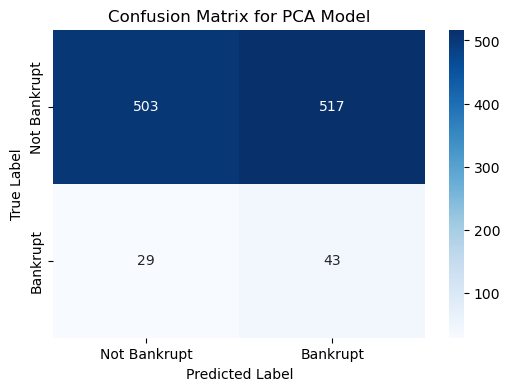


Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.49      0.65      1020
           1       0.08      0.60      0.14        72

    accuracy                           0.50      1092
   macro avg       0.51      0.55      0.39      1092
weighted avg       0.89      0.50      0.61      1092


False Positives (Predicted Bankrupt but Survived):


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X55,X56,X57,X58,X59,X60,X61,X62,X63,X64
1,-0.023834,0.210100,0.508390,4.2374,22.034,0.058412,-0.027621,3.65790,0.98183,0.76855,...,38823.0000,-0.018502,-0.031011,1.018500,0.069047,5.7996,7.7529,26.446,13.8020,6.4782
5,0.030779,0.430120,0.044111,1.1569,806.420,0.000000,0.043742,0.76923,1.07020,0.33086,...,1.1569,1.000000,0.093029,0.094416,0.815010,9.7999,8.6220,95.866,3.8074,2.4881
7,0.144750,0.072429,0.385560,6.3233,66.903,0.492910,0.144750,12.79300,1.06340,0.92662,...,6083.6000,0.059624,0.156220,0.940380,0.000000,52.2790,128.1600,13.042,27.9870,3.7400
10,0.007816,0.385260,0.258470,1.6709,-41.192,0.095907,0.015741,1.55320,1.02140,0.59838,...,29370.0000,0.020924,0.013062,0.979080,0.000000,3.1856,5.1372,115.970,3.1473,3.4033
11,0.010261,0.439130,0.045303,1.1116,-50.568,0.152180,0.011530,1.06770,1.00500,0.46885,...,2936.5000,0.004989,0.021886,0.995010,0.070557,6.2262,6.7034,106.300,3.4338,2.5413



False Negatives (Predicted Safe but Actually Bankrupt):


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X55,X56,X57,X58,X59,X60,X61,X62,X63,X64
30,-0.146680,0.62152,-0.177320,0.58311,-90.946,-0.019106,-0.146680,0.60894,0.86202,0.37847,...,-1104.00,0.279250,-0.38756,1.1668,0.402410,12.4830,5.0228,180.100,2.02670,1.1463
36,0.058425,0.48000,0.531880,2.15070,77.738,0.000000,0.074435,1.08310,2.54600,0.51988,...,4521.00,0.035072,0.11238,0.9645,0.000000,17739.0000,7.6932,66.267,5.50800,433.6000
77,0.046136,0.58764,0.061231,1.12780,-40.801,0.046136,0.060462,0.45953,1.05900,0.27004,...,4537.20,0.055699,0.17085,0.9443,0.401940,6.5538,3.5131,146.200,2.49660,2.6022
84,-0.197690,2.05690,-1.406900,0.30958,-473.450,-1.332800,-0.192100,-0.51384,1.02740,-1.05690,...,-97797.00,-0.090187,0.18704,1.1163,-0.017586,12.1600,1.8846,723.930,0.50419,2.7831
146,-0.455720,2.73130,-1.754700,0.34974,-84.247,-2.724300,-0.455720,-0.63443,9.63360,-1.73280,...,-748.45,-0.015089,0.26299,1.0166,0.000000,18.6270,132.6800,102.240,3.56990,171.3500


In [67]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.calibration import calibration_curve

y_train_resampled_trimmed = y_train_resampled[:len(y_pred_pca)]
X_train_resampled_trimmed = X_train_resampled.iloc[:len(y_pred_pca), :]  

accuracy_pca = accuracy_score(y_train_resampled_trimmed, y_pred_pca)
recall_pca = recall_score(y_train_resampled_trimmed, y_pred_pca, pos_label=1, average="binary")
precision_pca = precision_score(y_train_resampled_trimmed, y_pred_pca, pos_label=1, average="binary")
f1_pca = f1_score(y_train_resampled_trimmed, y_pred_pca, average="binary")
auc_pca = roc_auc_score(y_train_resampled_trimmed, y_pred_pca)  

print("\tPCA Model - Accuracy: {a:3.1%}, Recall: {r:3.1%}, Precision: {p:3.1%}, F1 Score: {f1:3.3f}, AUC: {auc:3.3f}".format(
    a=accuracy_pca,
    r=recall_pca,
    p=precision_pca,
    f1=f1_pca,
    auc=auc_pca
))

cm = confusion_matrix(y_train_resampled_trimmed, y_pred_pca)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Not Bankrupt', 'Bankrupt'], yticklabels=['Not Bankrupt', 'Bankrupt'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix for PCA Model")
plt.show()

print("\nClassification Report:\n", classification_report(y_train_resampled_trimmed, y_pred_pca))

false_positives = X_train_resampled_trimmed[(y_pred_pca == 1) & (y_train_resampled_trimmed == 0)]
false_negatives = X_train_resampled_trimmed[(y_pred_pca == 0) & (y_train_resampled_trimmed == 1)]
print("\nFalse Positives (Predicted Bankrupt but Survived):")
display(false_positives.head())
print("\nFalse Negatives (Predicted Safe but Actually Bankrupt):")
display(false_negatives.head())


The notebook walks through the entire machine learning project to predict whether a company will go bankrupt based on financial attributes. It starts by defining the problem—helping businesses assess bankruptcy risk—and acquiring the dataset, which contains 64 financial features for different companies. First I tried renaming the features with their original names but it wasn't of much use. The exploratory data analysis dives into understanding the data, identifying missing values, checking for class imbalance, and visualizing correlations to detect multicollinearity. Techniques like checking the correlation, correlation matrix, feature frequencies, and plots to check bankruptcy data implance were implemented.  Next, the data is preprocessed by handling missing values, converting categorical variables, scaling features, and splitting it into training and testing sets. A lot of techniques like SMOTE(to balance bankruptcy data) and Imputer(to fill missing data with mean) were implemeted. Later to check for more accuracy for the model, dimensionality reduction was used to improve model performance, Principal Component Analysis (PCA) is applied. 

The modeling phase was experimented with multiple classifiers, including Random Forest, Logistic Regression, Decision Tree, SVM, and KNN, evaluating them using accuracy, recall, and precision. Finalized RandomForest and Logistic Regression was selected to model. GridSearchCV was employed to fine-tune hyperparameters for both Random Forest and Logistic Regression. To further enhance predictions, classification thresholds are optimized for a better balance between recall and precision. Ultimately the LogisticRegression was employed as the final model for this project. The notebook concludes with insights into which financial factors contribute most to bankruptcy predictions, offering a valuable tool for financial risk assessment. Further improvements could include experimenting with deep learning models, ensemble techniques, or feature engineering using financial ratios to refine predictions. In the end the error analysis was done for the project with confusion matrix and Classification Report

Lastly, a lot of experimentation was done before submitting the final work. This is in no way the result possible, a lot of things could've been done better. I tried my best to strike a balance between precision, recall and accuracy. I experimented with a lot of models and techniques in a lot of ipynb notebooks. I understand the work could've been done in a better way. 